# F500 Problem Set 1

## Exercice 1

First obtain daily price data on a stock index and two individual stocks from a market of your choice. The method for assignment is given below. The calculations can be performed in Excel and/or Eviews, but also in other software packages, as you prefer.

### 1.a)

Compute the sample statistics of the stock return (computed from the daily closing price) series, i.e., the mean, standard deviation, skewness and kurtosis. You may ignore dividends and just focus on capital gain.

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns


The two stocks I am analysing are from the SMI. I will analyse UBS stocks and Lonza stocks.
I am downloading 20 years of daily data.

The columns of the dataset are:

- open: price at which the stock first traded when the market opened that day (reflects overnight information)
- high: highest transaction price reached during that trading day
- low: lowest transaction price during that trading day
- close: final traded price at market close
- adj close: closing price adjusted for dividends, stock splits and corporate actions (reflects the true capital gain including reinvested dividends)
- volume: number of shares during the day



In [4]:
tickers = ["UBSG.SW", "LONN.SW", "^SSMI"]

df = yf.download(
    tickers,
    start="2005-01-01",
    end="2025-01-01",
    interval="1d",
    auto_adjust=False
)


[*********************100%***********************]  3 of 3 completed


In [5]:
# Compute daily simple returns from closing prices (ignoring dividends)
close = df['Close']
returns = close.pct_change().dropna()

# pct_change() is build in pandas and computes the percentage change between consecutive rows.
# r_t = (P_t - P_{t-1}) / P_{t-1}

# skew() is a measure of asymmetry
# kurtosis() measures howw heavy are the tails compared to a normal distribution.

# Sample statistics
stats = pd.DataFrame({
    "Mean": returns.mean(),
    "Std Dev": returns.std(),
    "Skewness": returns.skew(),
    "Kurtosis (Excess)": returns.kurtosis()
})

print(stats)


             Mean   Std Dev  Skewness  Kurtosis (Excess)
Ticker                                                  
LONN.SW  0.000604  0.018527 -1.148737          15.564201
UBSG.SW  0.000149  0.022844  0.582286          15.954942
^SSMI    0.000192  0.010506 -0.224584           9.940244


We are studying returns, not prices. Raw prices are not directly comparable across stocks. Percentages normalize it and gives a rate of return that is comparable and unit free.

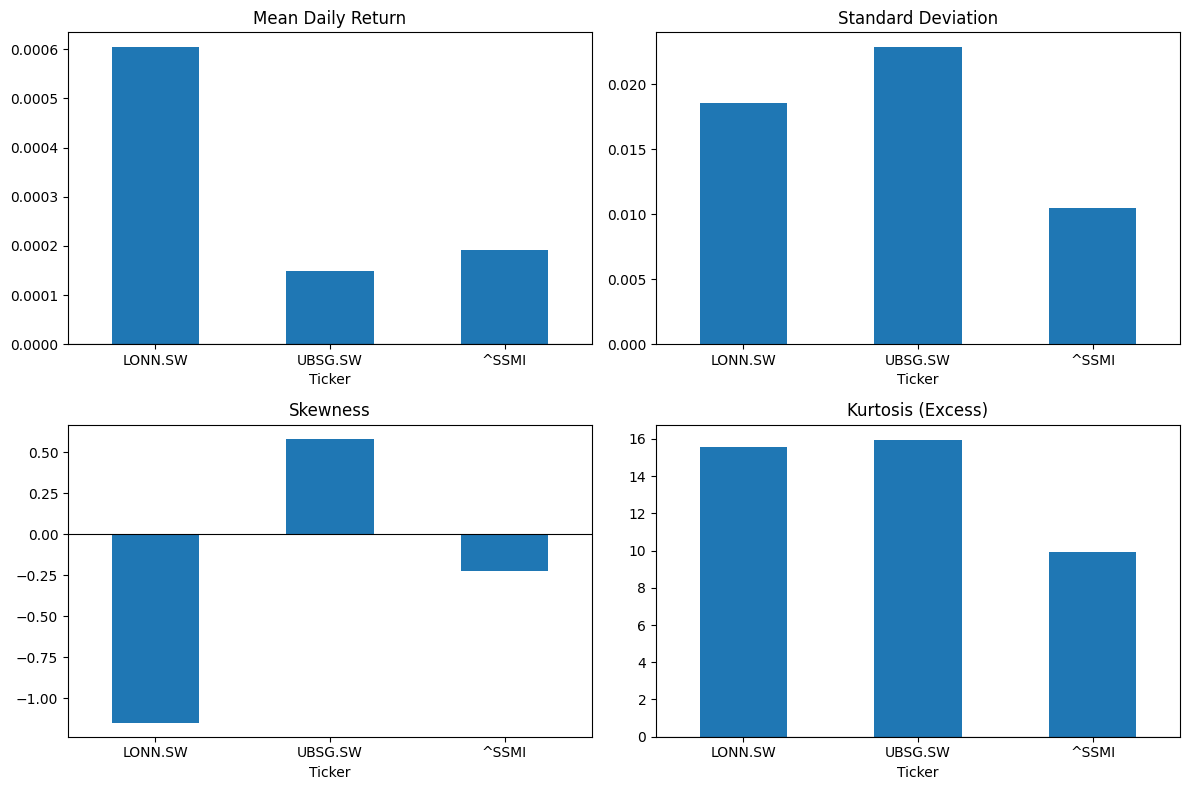

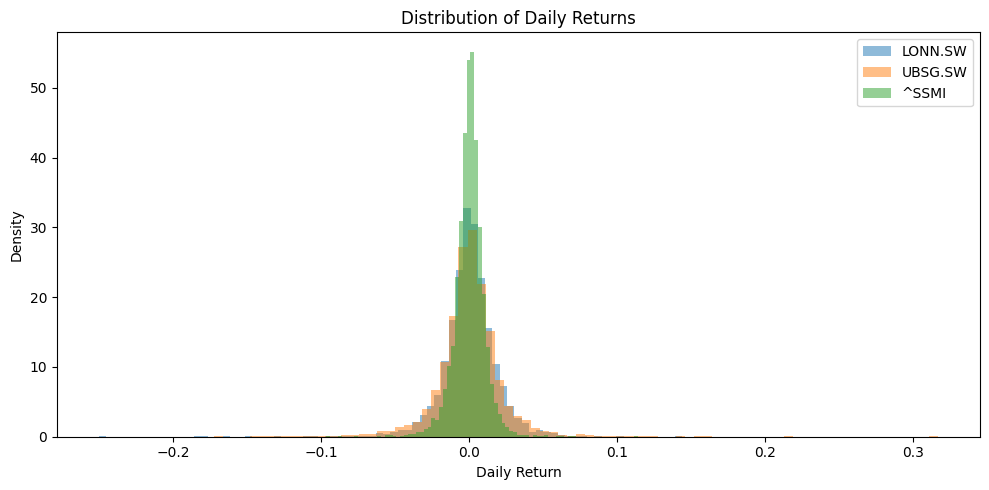

In [6]:
# Bar charts comparing summary statistics across the three series
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

stats['Mean'].plot(kind='bar', ax=axes[0, 0], title='Mean Daily Return')
axes[0, 0].axhline(0, color='k', linewidth=0.8)

stats['Std Dev'].plot(kind='bar', ax=axes[0, 1], title='Standard Deviation')

stats['Skewness'].plot(kind='bar', ax=axes[1, 0], title='Skewness')
axes[1, 0].axhline(0, color='k', linewidth=0.8)

stats['Kurtosis (Excess)'].plot(kind='bar', ax=axes[1, 1], title='Kurtosis (Excess)')
axes[1, 1].axhline(0, color='k', linewidth=0.8)

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Overlaid histograms to compare return distributions
fig, ax = plt.subplots(figsize=(10, 5))
for col in returns.columns:
    ax.hist(returns[col], bins=80, alpha=0.5, label=col, density=True)
ax.set_xlabel('Daily Return')
ax.set_ylabel('Density')
ax.set_title('Distribution of Daily Returns')
ax.legend()
plt.tight_layout()
plt.show()



Lonza has the highest mean daily return, but also high volatility.
UBS has moderate return but with a higher volatility to Lonza.
SMI has the lowest return but also a much lowest volatility.

The skewness is negative for most stocks, which show that they usually have more frequent large negative returns than positive ones. UBS has a positive skewness which means it has more frequent small losses, but occasional large gains.

The fat tails indicate that extreme events occur much more frequently than a normal distribution would predict.

### 1b)
Compute the first 20 autocorrelation coefficients and test whether the series is linearly predictable or not.

In [7]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Compute first 20 autocorrelation coefficients
n_lags = 20

autocorr = pd.DataFrame(
    {col: [returns[col].autocorr(lag=i) for i in range(1, n_lags + 1)]
     for col in returns.columns},
    index=range(1, n_lags + 1)
)
autocorr.index.name = 'Lag'
print(autocorr)

# Each column is a stock, each row is a lag, each cell is the autocorrelation at that lag.
# The dictionnary comprehension is similar to that loop:
# result = {}
# for col in returns.columns:          # loop over each stock
#     values = []
#     for i in range(1, 21):            # loop over lags 1 to 20
#         ac = returns[col].autocorrelation(lag=i)  # corr(r_t, r_{t-i})
#         values.append(ac)
#     result[col] = values


      LONN.SW   UBSG.SW     ^SSMI
Lag                              
1    0.028283  0.075067  0.020277
2   -0.015577 -0.053440 -0.063034
3   -0.006156 -0.061464 -0.027157
4   -0.025325 -0.029631  0.036484
5   -0.024744 -0.003158 -0.055926
6    0.002259 -0.034834 -0.040939
7    0.025045 -0.018303  0.002122
8    0.004488  0.012441  0.005677
9   -0.008269  0.033603 -0.012845
10  -0.028112  0.005973  0.018960
11   0.018305 -0.033273 -0.000549
12   0.011454 -0.016310  0.001053
13  -0.005099 -0.025261 -0.024022
14  -0.018223 -0.026198 -0.024637
15  -0.002988 -0.006984 -0.017337
16   0.024306  0.057256  0.039285
17  -0.006663  0.020825 -0.011761
18  -0.005279 -0.013218 -0.015373
19  -0.006123 -0.002370  0.006530
20  -0.011222 -0.025757  0.006755


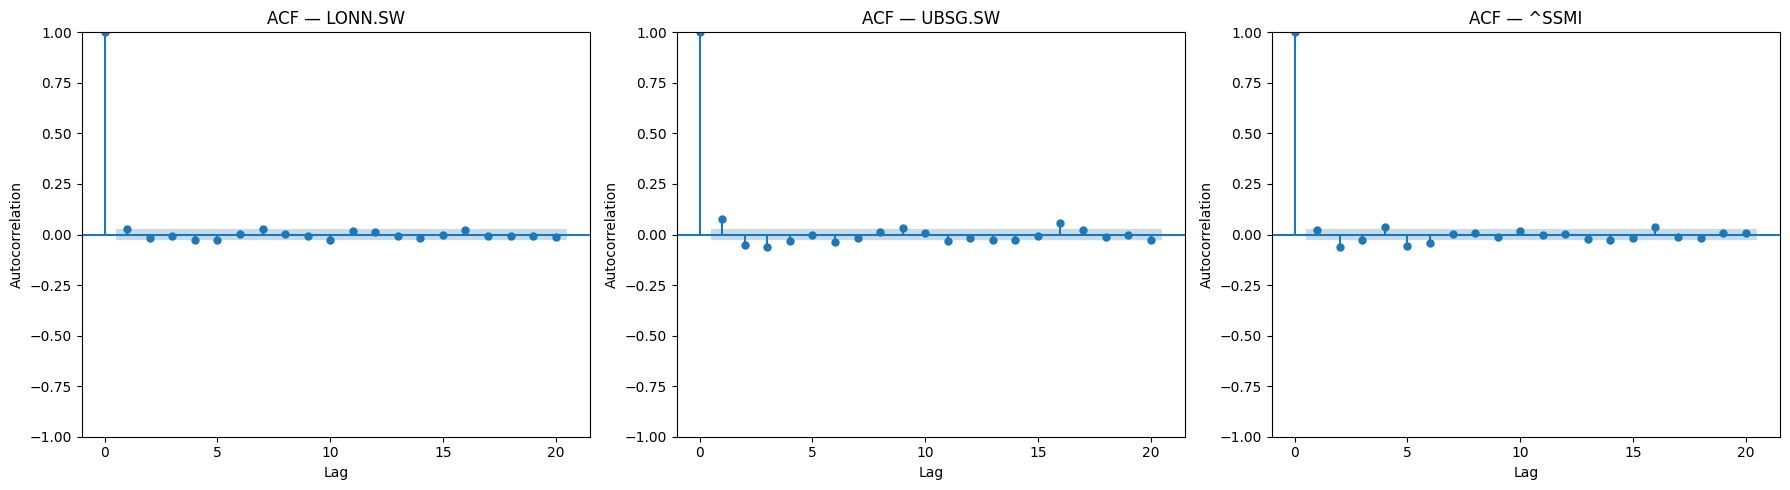

In [8]:
# Plot autocorrelation functions (ACF)
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, returns.columns):
    plot_acf(returns[col], lags=n_lags, ax=ax, title=f'ACF — {col}')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
plt.tight_layout()
plt.show()


In [9]:
# Ljung-Box test for joint significance of autocorrelations
# it combines all k autocorrelation into a single test statistic
# if markets are efficient, past returns should not help predict future returns, today's price already reflect all available information.
# Returns should behave roughly like a random walk, meaning autocorrelations should be zero.
# Non-zero autocorrelation implies linear predictability.

# H0: the first k autocorrelations are all zero (no linear predictability)
# H1: at least one autocorrelation is non-zero



# It test wheter a time seris has significant autocorrelation (wheter past returns help predict future returns).
# If a market is efficient, returns should be unpredictable, so all autocorrelations should be zero.

pd.set_option('display.max_rows', None)

col = "UBSG.SW"
lb_test = acorr_ljungbox(returns[col], lags=n_lags, return_df=True)
print(f"--- Ljung-Box Test: {col} ---")
print(lb_test)
p_val_20 = lb_test['lb_pvalue'].iloc[-1]
if p_val_20 < 0.05:
    print(f"=> Reject H0 at 5%: {col} returns show significant linear predictability.")
else:
    print(f"=> Cannot reject H0 at 5%: {col} returns show no significant linear predictability.")


--- Ljung-Box Test: UBSG.SW ---
       lb_stat     lb_pvalue
1    28.163709  1.114753e-07
2    42.436803  6.094882e-10
3    61.320129  3.070164e-13
4    65.709585  1.823749e-13
5    65.759432  7.797129e-13
6    71.824819  1.726124e-13
7    73.499666  2.890931e-13
8    74.273619  6.894153e-13
9    79.920707  1.675817e-13
10   80.099129  4.800795e-13
11   85.637111  1.187380e-13
12   86.967834  1.902397e-13
13   90.160581  1.302122e-13
14   93.595109  7.910313e-14
15   93.839244  1.896125e-13
16  110.250647  4.019096e-16
17  112.422001  4.219125e-16
18  113.296913  7.631159e-16
19  113.325044  1.937544e-15
20  116.648102  1.186613e-15
=> Reject H0 at 5%: UBSG.SW returns show significant linear predictability.


In [10]:
col = "LONN.SW"
lb_test = acorr_ljungbox(returns[col], lags=n_lags, return_df=True)
print(f"--- Ljung-Box Test: {col} ---")
print(lb_test)
p_val_20 = lb_test['lb_pvalue'].iloc[-1]
if p_val_20 < 0.05:
    print(f"=> Reject H0 at 5%: {col} returns show significant linear predictability.")
else:
    print(f"=> Cannot reject H0 at 5%: {col} returns show no significant linear predictability.")


--- Ljung-Box Test: LONN.SW ---
      lb_stat  lb_pvalue
1    3.997893   0.045557
2    5.210760   0.073875
3    5.400227   0.144729
4    8.607206   0.071703
5   11.668170   0.039629
6   11.693684   0.069162
7   14.830449   0.038235
8   14.930965   0.060502
9   15.272072   0.083729
10  19.209371   0.037683
11  20.879056   0.034646
12  21.532890   0.043101
13  21.662495   0.060817
14  23.318005   0.055288
15  23.362508   0.076741
16  26.307673   0.049850
17  26.528728   0.065351
18  26.667537   0.085446
19  26.854135   0.108097
20  27.481155   0.122262
=> Cannot reject H0 at 5%: LONN.SW returns show no significant linear predictability.


In [11]:
col = "^SSMI"
lb_test = acorr_ljungbox(returns[col], lags=n_lags, return_df=True)
print(f"--- Ljung-Box Test: {col} ---")
print(lb_test)
p_val_20 = lb_test['lb_pvalue'].iloc[-1]
if p_val_20 < 0.05:
    print(f"=> Reject H0 at 5%: {col} returns show significant linear predictability.")
else:
    print(f"=> Cannot reject H0 at 5%: {col} returns show no significant linear predictability.")


--- Ljung-Box Test: ^SSMI ---
      lb_stat     lb_pvalue
1    2.054984  1.517088e-01
2   21.911710  1.745551e-05
3   25.597700  1.157814e-05
4   32.251332  1.699651e-06
5   47.878391  3.760845e-09
6   56.252546  2.588012e-10
7   56.275058  8.328193e-10
8   56.436149  2.319571e-09
9   57.260881  4.504324e-09
10  59.057905  5.461197e-09
11  59.059410  1.385705e-08
12  59.064953  3.340381e-08
13  61.950642  2.346876e-08
14  64.986514  1.538306e-08
15  66.490111  1.869908e-08
16  74.211682  1.805072e-09
17  74.903895  3.036605e-09
18  76.086748  4.108329e-09
19  76.300228  8.004318e-09
20  76.528687  1.512375e-08
=> Reject H0 at 5%: ^SSMI returns show significant linear predictability.


The returns of the SMI and UBS show significant linear predictability.

### 1c) 
Does it make a difference whether you compute returns using log price differences or as actual return?

Simple return:

$ R_t = (P_t - P_{t-1}) / P_{t-1} $

Log return:

$ r_t = ln(P_t) - ln(P_{t-1}) = ln(1 + R_t) $

For small returns, the two are nearly identical. The difference becomes meaningfull for larger returns.


In [12]:
log_returns = np.log(close / close.shift(1)).dropna()

log_stats = pd.DataFrame({
    "Mean": log_returns.mean(),
    "Std Dev": log_returns.std(),
    "Skewness": log_returns.skew(),
    "Kurtosis (Excess)": log_returns.kurtosis()
})

print("Simple returns:")
print(stats)
print("\nLog returns:")
print(log_stats)


Simple returns:
             Mean   Std Dev  Skewness  Kurtosis (Excess)
Ticker                                                  
LONN.SW  0.000604  0.018527 -1.148737          15.564201
UBSG.SW  0.000149  0.022844  0.582286          15.954942
^SSMI    0.000192  0.010506 -0.224584           9.940244

Log returns:
             Mean   Std Dev  Skewness  Kurtosis (Excess)
Ticker                                                  
LONN.SW  0.000430  0.018773 -1.679511          21.920351
UBSG.SW -0.000111  0.022781  0.040993          12.886273
^SSMI    0.000136  0.010523 -0.410571           9.923418


Here, we can infer that the statistcis are really close because for daily data when returns are small, the choice of method does not make a big difference.

## Exercice 2

Moving average


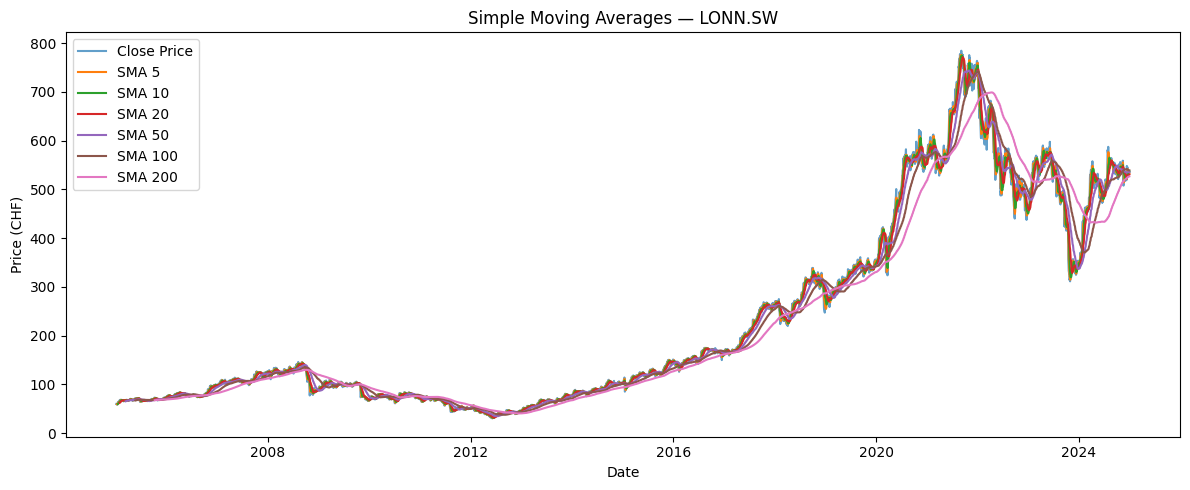

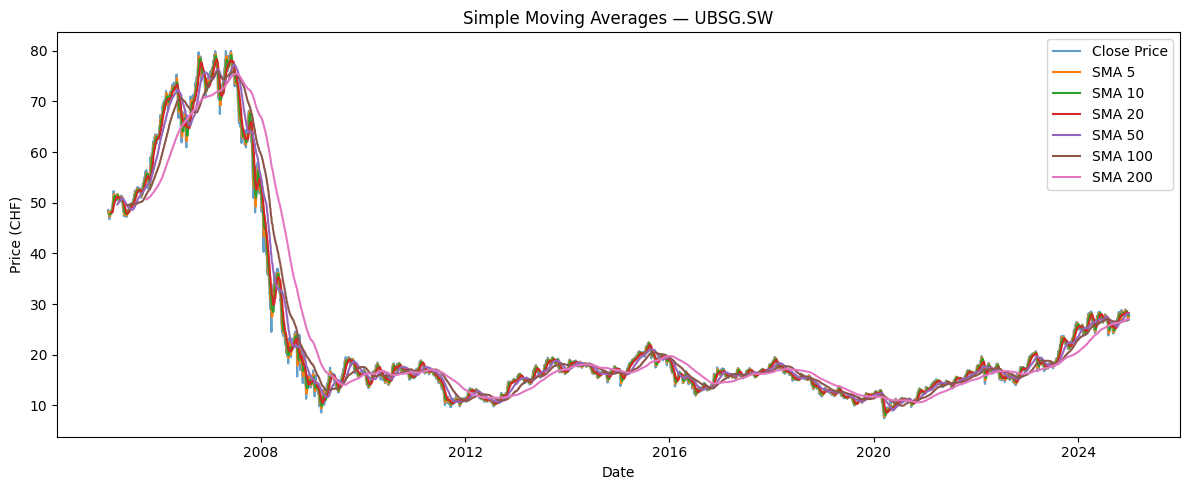

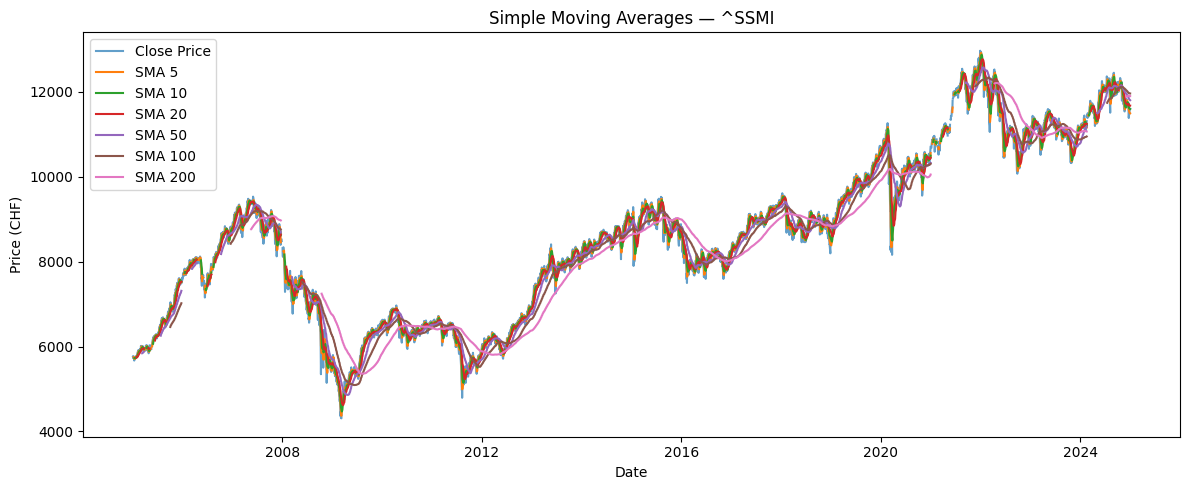

In [13]:
windows = [5, 10, 20, 50, 100, 200]

for col in close.columns:
    plt.figure(figsize=(12, 5))
    plt.plot(close[col], label='Close Price', alpha=0.7)
    
    for w in windows:
        sma = close[col].rolling(window=w).mean()
        plt.plot(sma, label=f'SMA {w}')
    
    plt.title(f'Simple Moving Averages — {col}')
    plt.xlabel('Date')
    plt.ylabel('Price (CHF)')
    plt.legend()
    plt.tight_layout()
    plt.show()


EWMA: With λ = 2/(w+1), it gives more weight to recent prices.

Trading strategies:

- momentum startegy: buy when price is above MA, sell when below - betting the trend continues.
- contrarian strategy: buy when price below MA, sell when above - betting on mean reversion.

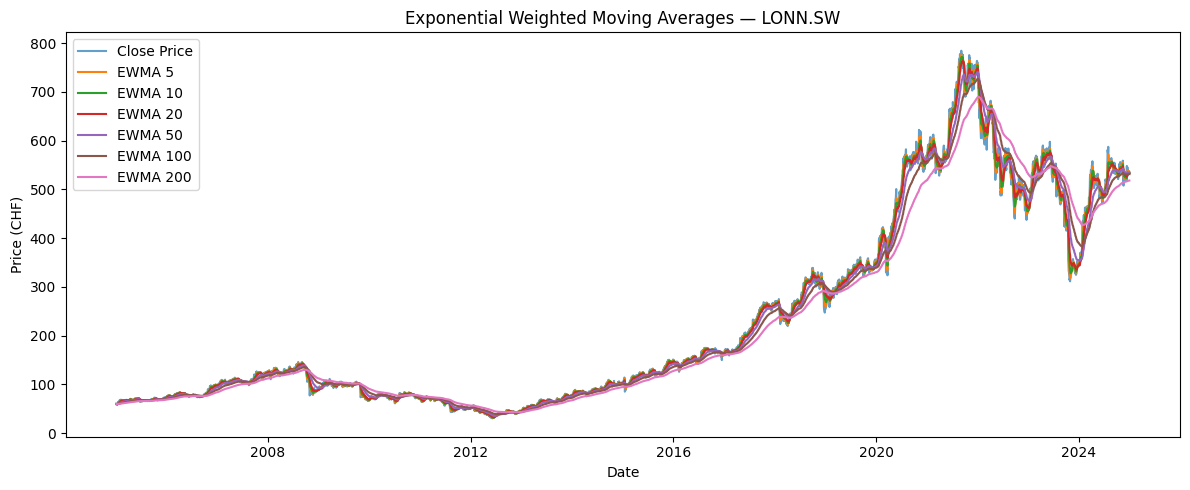

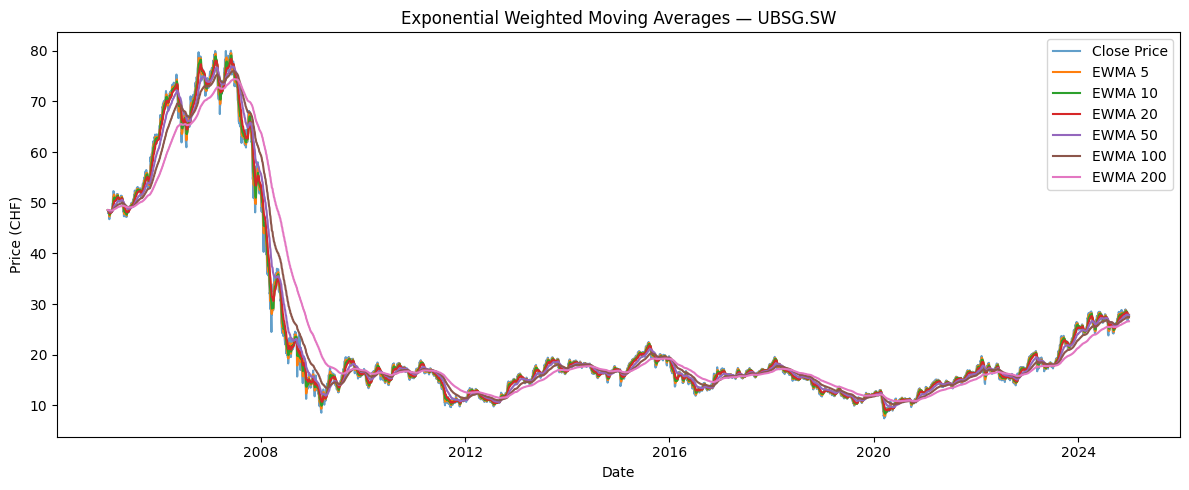

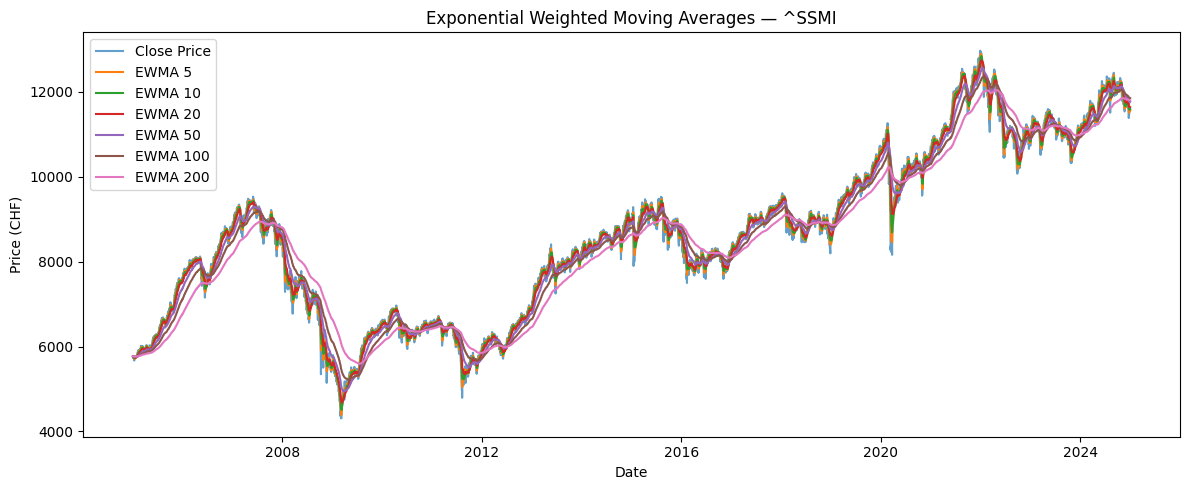

In [14]:
# EWMA for each window
windows = [5, 10, 20, 50, 100, 200]

for col in close.columns:
    plt.figure(figsize=(12, 5))
    plt.plot(close[col], label='Close Price', alpha=0.7)
    
    for w in windows:
        ewma = close[col].ewm(span=w, adjust=False).mean()
        plt.plot(ewma, label=f'EWMA {w}')
    
    plt.title(f'Exponential Weighted Moving Averages — {col}')
    plt.xlabel('Date')
    plt.ylabel('Price (CHF)')
    plt.legend()
    plt.tight_layout()
    plt.show()


Buy and hold strategy: simplest possible investment strategy, buy an asset and hold it for a long time, regardless of short-term price fluctuations, it survives volatility because long-run growth dominates.

In [15]:
# Backtest contrarian and momentum strategies

# This tests wheter startegies based on moving averages can beat buy & hold approach.
results = []

for col in close.columns:
    for w in windows:
        ewma = close[col].ewm(span=w, adjust=False).mean() #computes and exponentially weighted moving average of the price
        daily_ret = close[col].pct_change() #daily return of the stock
        
        # Signal: compare price to EWMA
        # Momentum: buy (1) when price > EWMA, sell (-1) when price < EWMA
        momentum_signal = np.where(close[col] > ewma, 1, -1) #when price above average, buy (+1), otherwise sell (-1)
        # Contrarian: opposite #bet that the trend will reverse
        contrarian_signal = -momentum_signal
        
        # Strategy returns: signal from yesterday applied to today's return
        # Shift signal by 1 to avoid look-ahead bias
        momentum_ret = daily_ret * pd.Series(momentum_signal, index=close[col].index).shift(1) #shift(1) means you use yesterday's signal to trade today
        contrarian_ret = daily_ret * pd.Series(contrarian_signal, index=close[col].index).shift(1)
        
        results.append({
            'Stock': col,
            'Window': w,
            'Buy & Hold (ann.)': daily_ret.mean() * 252,
            'Momentum (ann.)': momentum_ret.mean() * 252,
            'Contrarian (ann.)': contrarian_ret.mean() * 252,
        })

results_df = pd.DataFrame(results)

for col in close.columns:
    print(f"\n--- {col} ---")
    subset = results_df[results_df['Stock'] == col].set_index('Window')
    print(subset[['Buy & Hold (ann.)', 'Momentum (ann.)', 'Contrarian (ann.)']].to_string())



--- LONN.SW ---
        Buy & Hold (ann.)  Momentum (ann.)  Contrarian (ann.)
Window                                                       
5                0.153255        -0.018021           0.018021
10               0.153255         0.026989          -0.026989
20               0.153255         0.029486          -0.029486
50               0.153255         0.043455          -0.043455
100              0.153255         0.016131          -0.016131
200              0.153255         0.086501          -0.086501

--- UBSG.SW ---
        Buy & Hold (ann.)  Momentum (ann.)  Contrarian (ann.)
Window                                                       
5                0.037027         0.145988          -0.145988
10               0.037027         0.141850          -0.141850
20               0.037027         0.054926          -0.054926
50               0.037027        -0.018492           0.018492
100              0.037027         0.046647          -0.046647
200              0.037027        -0.

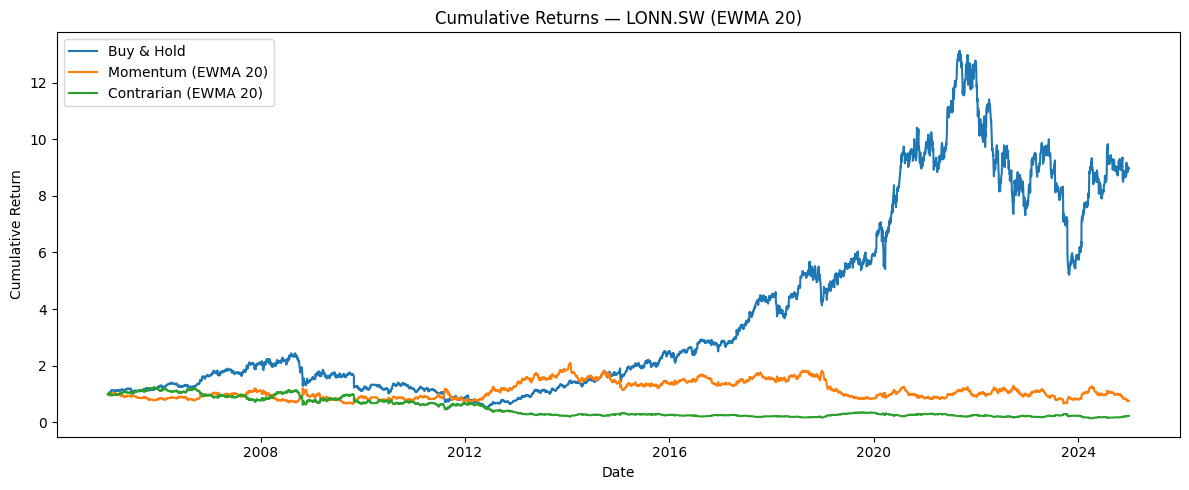

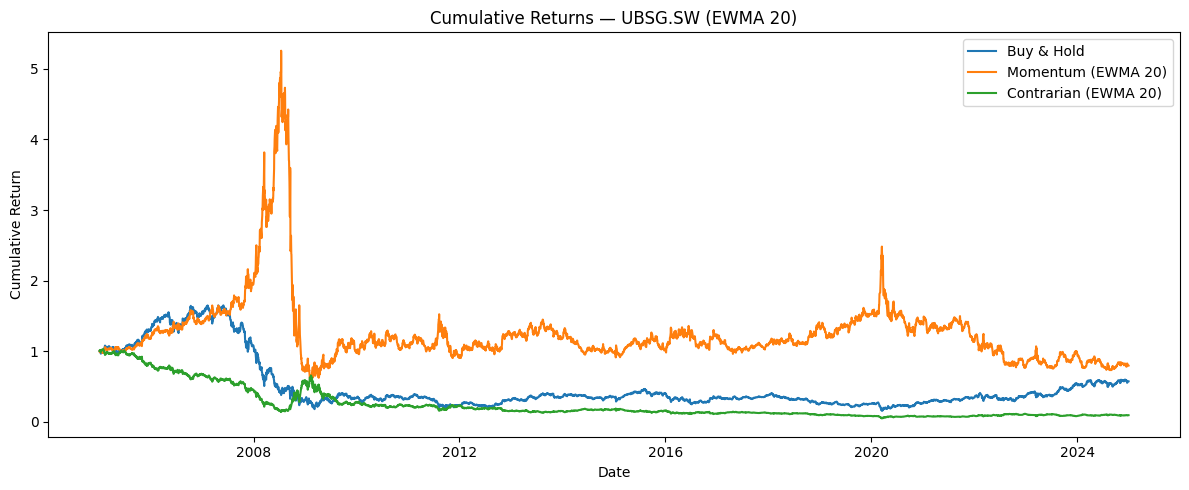

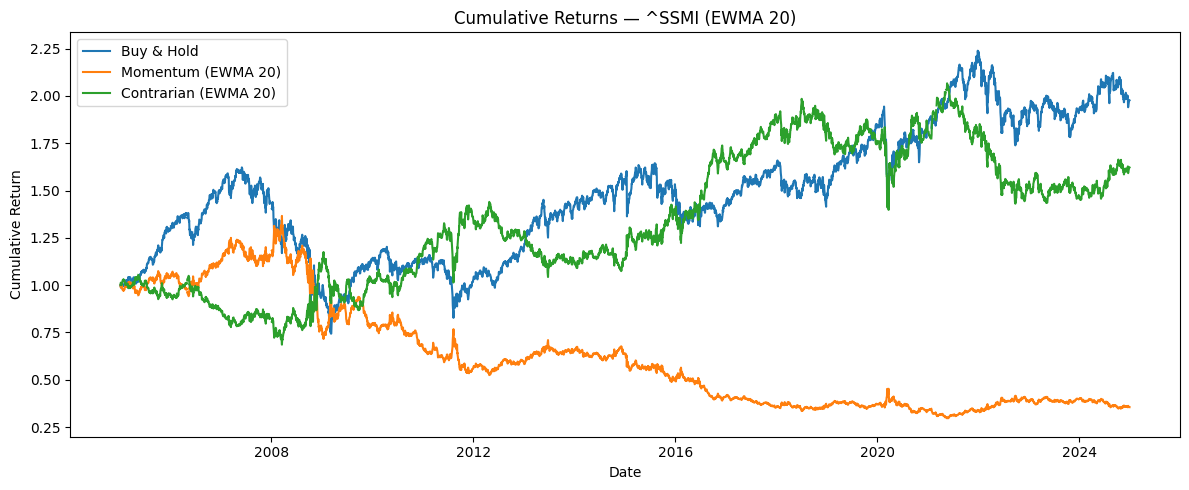

In [16]:
# Cumulative returns plot for a chosen window (e.g. 20-day)
w = 20

for col in close.columns:
    ewma = close[col].ewm(span=w, adjust=False).mean() # span sets lamba equal to 2/(20+1)
    # .mean() so that it computes the weighted average, ewm(span=w) sets up the exponential weighting scheme.
    daily_ret = close[col].pct_change()
    
    # generate trading signals
    momentum_signal = np.where(close[col] > ewma, 1, -1) # Momentum: buy (1) when price > EWMA, sell (-1) when price < EWMA
    contrarian_signal = -momentum_signal
    
    # shift(1) shift the signal by one day so that we are using yesterday's signal to trade today.
    # avoids look-ahead bias (can't act on information you don't have yet)

    momentum_ret = daily_ret * pd.Series(momentum_signal, index=close[col].index).shift(1)
    contrarian_ret = daily_ret * pd.Series(contrarian_signal, index=close[col].index).shift(1)
    
    # compute cumulative returns
    # buy-and)hold wealth process

    cum_bh = (1 + daily_ret).cumprod() #this here computes the wealth process (cumulative returns)
    cum_mom = (1 + momentum_ret).cumprod()
    cum_con = (1 + contrarian_ret).cumprod()
    
    plt.figure(figsize=(12, 5))
    plt.plot(cum_bh, label='Buy & Hold')
    plt.plot(cum_mom, label=f'Momentum (EWMA {w})')
    plt.plot(cum_con, label=f'Contrarian (EWMA {w})')
    plt.title(f'Cumulative Returns — {col} (EWMA {w})')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend()
    plt.tight_layout()
    plt.show()

# This is plotted as a wealth process (cumulative returns).



Lonza exhibits long-term upward trend and the 20 day momentum rule misses it As EWMA(20) is a short window, you frequently flip positions therefore you miss long uninterrupted compounding. Buy & Hold explodes over time.

UBS, buy & hold performs poorly, momentum performs well. UBS is cyclical and volatile, therefore the momentum strategy avoid large crashes. Momentum does well in crisis regimes, therefore when UBS collapsed momentum stayed short which generated large profits.

The 20-day EWMA rule is a very short-term signal and it works well in crisis/trending market, but fails in smooth long-term growth stocks and fail in low-volatility mean-reverting indices.

## Exercice 3

Bollinger bands: modification of the moving average rules that allow a margin of safety by allowing for time varying volatility.

Answer the questions:

Is the price relatively high or low?
Is volatility increasing or decreasing?

Middle Band -> MA
Upper Band -> MA + 2*sd
Lower Band -> MA - 2*sd

Wide bands: high volatility

Trading interpretations:

- Mean Reversion Strategy: buy near lower band, sell near upper band (assumes price reverts to average)
- Breakout Strategy: buy when price breaks above upper band (assumes strong trend continuation)

If returns were normal and independent,a bout 95% of observations should lie within +/- 2sd


The Bollinger Bands are a modification of moving average rules that account for time-varying volatility:

$$BB_t^U = SMA_t^k + 2 \cdot \sigma_t$$
$$BB_t^L = SMA_t^k - 2 \cdot \sigma_t$$

where $\sigma_t = \text{std}(X_t, X_{t-1}, \ldots, X_{t-k})$ is the rolling standard deviation over the same window $k$.

Two trading strategies:
- **Contrarian (mean-reversion):** buy when $X_t < BB_t^L$, sell when $X_t > BB_t^U$
- **Momentum:** buy when $X_t > BB_t^U$, sell when $X_t < BB_t^L$


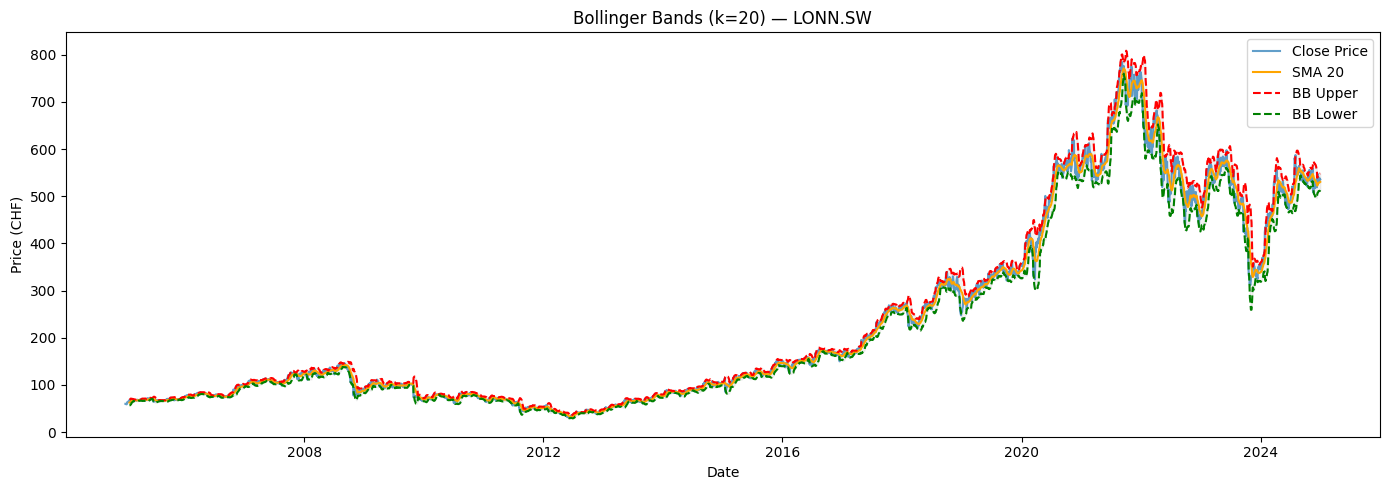

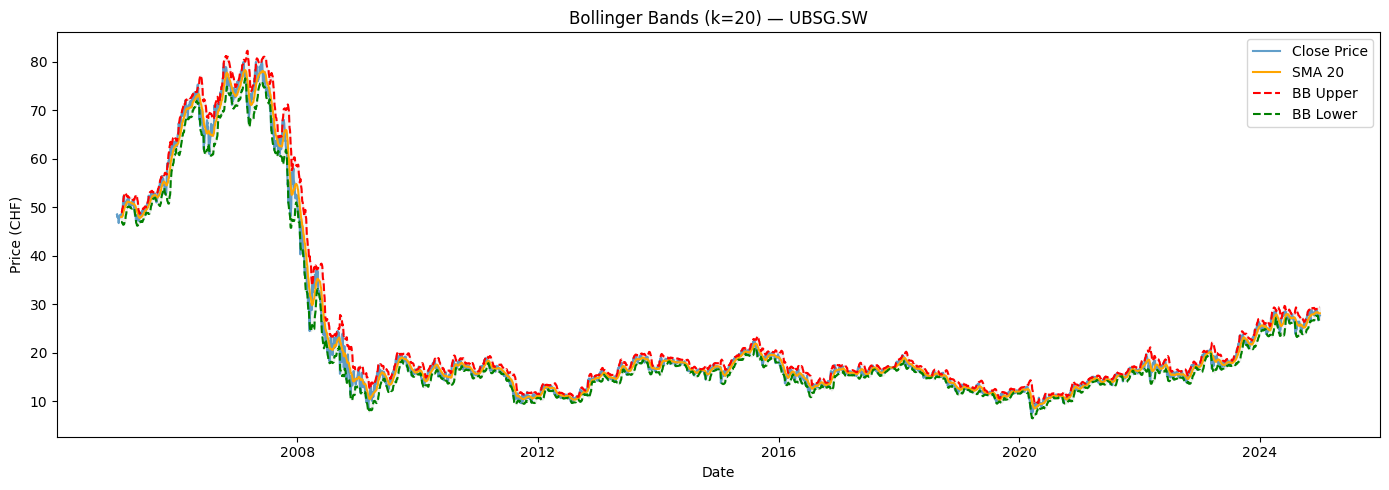

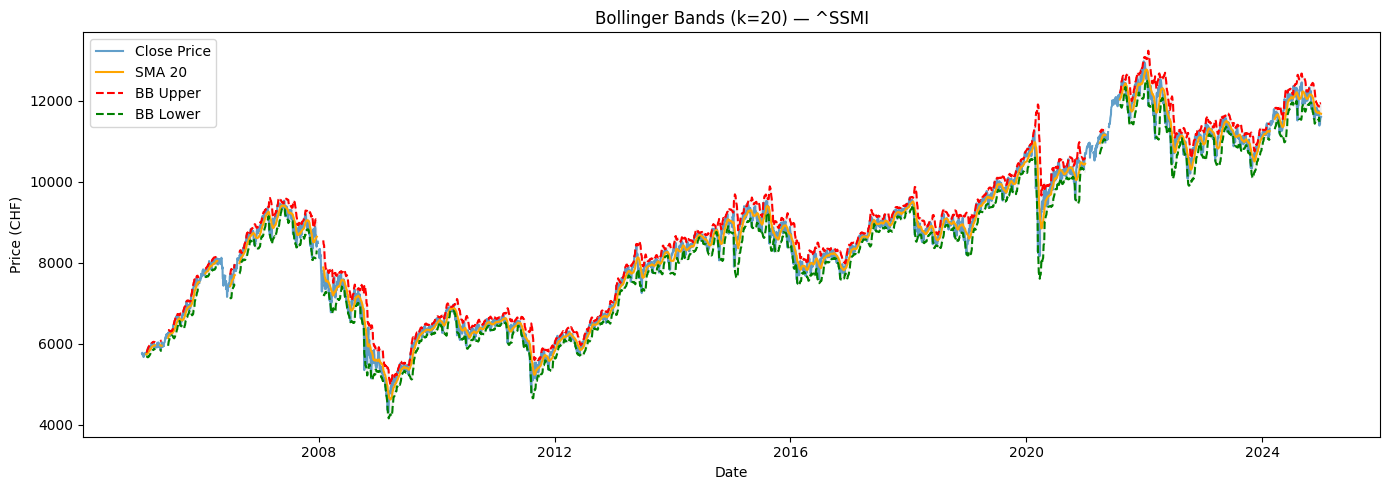

In [17]:
# Compute and plot Bollinger Bands for each stock
k = 20  # standard 20-day window

for col in close.columns:
    sma = close[col].rolling(window=k).mean() # k-day rolling mean of prices for that asset
    # here we are using a rolling window which means that all k observations get equal weight.
    sigma = close[col].rolling(window=k).std() # rk-day rolling standard deviation of prices
    
    bb_upper = sma + 2 * sigma
    bb_lower = sma - 2 * sigma
    
    plt.figure(figsize=(14, 5))
    plt.plot(close[col], label='Close Price', alpha=0.7)
    plt.plot(sma, label=f'SMA {k}', color='orange')
    plt.plot(bb_upper, label='BB Upper', color='red', linestyle='--')
    plt.plot(bb_lower, label='BB Lower', color='green', linestyle='--')
    plt.fill_between(close[col].index, bb_lower, bb_upper, alpha=0.1, color='grey')
    plt.title(f'Bollinger Bands (k={k}) — {col}')
    plt.xlabel('Date')
    plt.ylabel('Price (CHF)')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [18]:
# Backtest Bollinger Band strategies
bb_windows = [10, 20, 50]
bb_results = []

for col in close.columns:
    daily_ret = close[col].pct_change()
    
    for k in bb_windows:
        sma = close[col].rolling(window=k).mean()
        sigma = close[col].rolling(window=k).std()
        bb_upper = sma + 2 * sigma
        bb_lower = sma - 2 * sigma
        
        # Contrarian: buy when price < BB_lower, sell when price > BB_upper
        # Position: +1 (long) when below lower band, -1 (short) when above upper band, 0 otherwise
        contrarian_pos = pd.Series(0, index=close[col].index, dtype=float)
        # the 0 means we start at a flat position (0 = no position) for every day.

        contrarian_pos[close[col] < bb_lower] = 1
        contrarian_pos[close[col] > bb_upper] = -1
        # Forward-fill position: hold until opposite signal
        contrarian_pos = contrarian_pos.replace(0, np.nan).ffill().fillna(0)
        
        # Momentum: buy when price > BB_upper, sell when price < BB_lower
        momentum_pos = pd.Series(0, index=close[col].index, dtype=float)
        momentum_pos[close[col] > bb_upper] = 1
        momentum_pos[close[col] < bb_lower] = -1
        momentum_pos = momentum_pos.replace(0, np.nan).ffill().fillna(0)
        
        # .ffil(), forward fill the position which means that it carries the last non-NaN signal forward.
        # fillna(0) handles the start of the series before any signal fires, stay flat.

        # Strategy returns (shift position by 1 to avoid look-ahead bias)
        contrarian_ret = daily_ret * contrarian_pos.shift(1)
        momentum_ret = daily_ret * momentum_pos.shift(1)
        
        bb_results.append({
            'Stock': col,
            'Window': k,
            'Buy & Hold (ann.)': daily_ret.mean() * 252,
            'BB Contrarian (ann.)': contrarian_ret.mean() * 252,
            'BB Momentum (ann.)': momentum_ret.mean() * 252,
        })

bb_results_df = pd.DataFrame(bb_results)

for col in close.columns:
    print(f"\n--- {col} ---")
    subset = bb_results_df[bb_results_df['Stock'] == col].set_index('Window')
    print(subset[['Buy & Hold (ann.)', 'BB Contrarian (ann.)', 'BB Momentum (ann.)']].to_string())



--- LONN.SW ---
        Buy & Hold (ann.)  BB Contrarian (ann.)  BB Momentum (ann.)
Window                                                             
10               0.153255             -0.053511            0.053511
20               0.153255             -0.046915            0.046915
50               0.153255              0.050541           -0.050541

--- UBSG.SW ---
        Buy & Hold (ann.)  BB Contrarian (ann.)  BB Momentum (ann.)
Window                                                             
10               0.037027             -0.111673            0.111673
20               0.037027              0.009267           -0.009267
50               0.037027              0.038382           -0.038382

--- ^SSMI ---
        Buy & Hold (ann.)  BB Contrarian (ann.)  BB Momentum (ann.)
Window                                                             
10               0.048321              0.032722           -0.032722
20               0.048321              0.050623           -0.050623

Lonza has a strong long-term upward trend.

UBS is more cyclical and has less strucutral growth.

SMI has positive results for all the cells for the contrarian strategy. It means that the index exhibits mean reversion. Indeed, because diversification reduces frim-specific momentum, indexes tend to show less momentum.

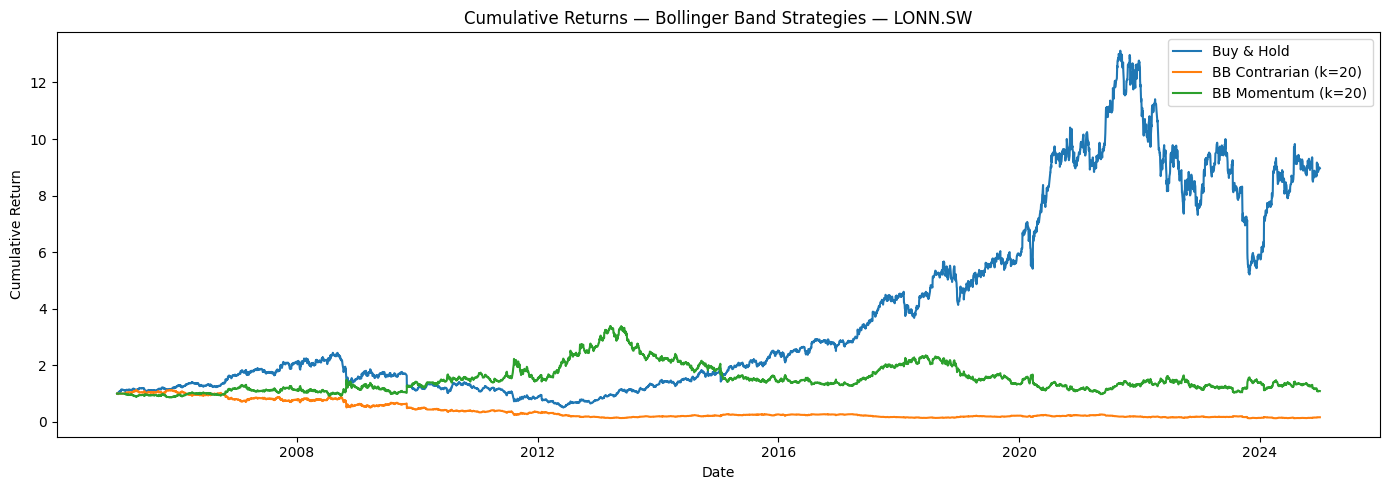

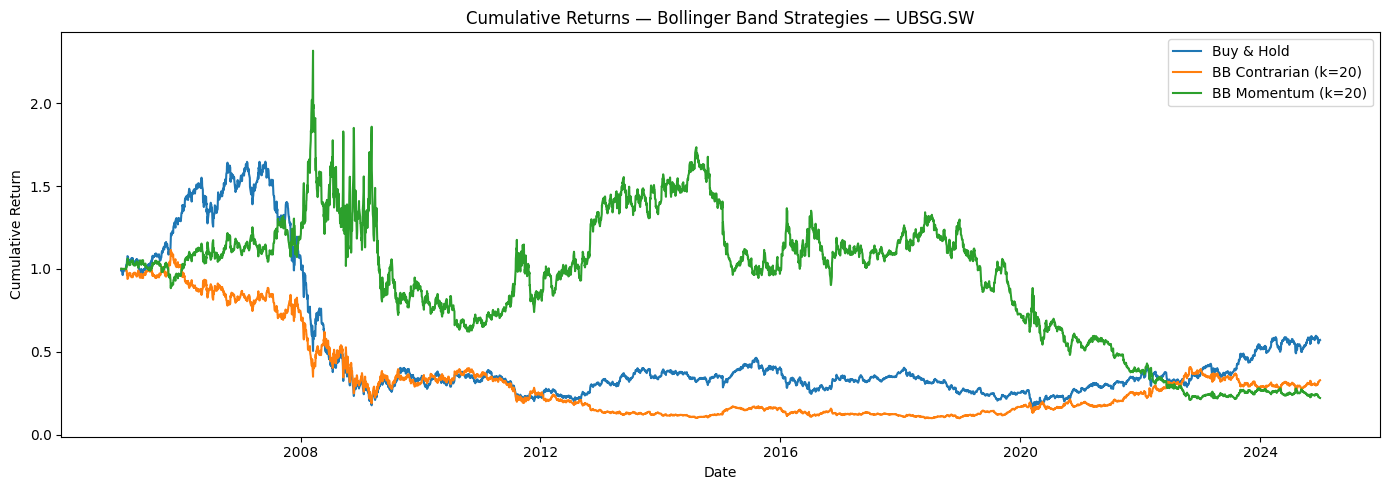

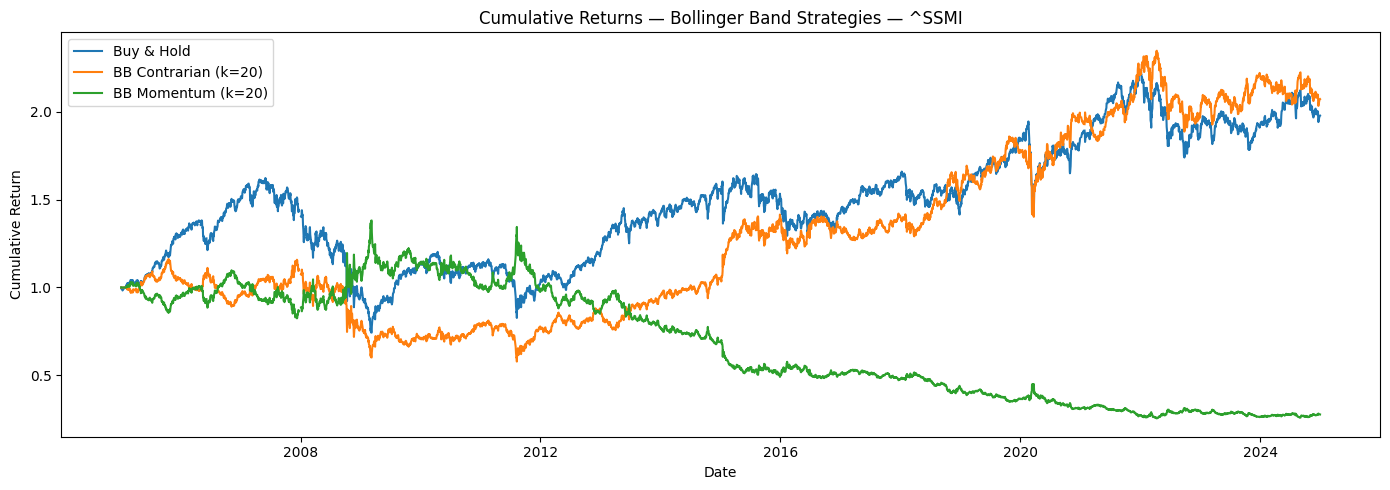

In [19]:
# Cumulative returns for Bollinger Band strategies (k=20)
k = 20

# for each asset: convert prices into daily returns

for col in close.columns:
    daily_ret = close[col].pct_change()
    sma = close[col].rolling(window=k).mean()
    sigma = close[col].rolling(window=k).std()
    bb_upper = sma + 2 * sigma
    bb_lower = sma - 2 * sigma
    
    # Contrarian position

    # trun into trading signals

    contrarian_pos = pd.Series(0, index=close[col].index, dtype=float)
    contrarian_pos[close[col] < bb_lower] = 1
    contrarian_pos[close[col] > bb_upper] = -1
    contrarian_pos = contrarian_pos.replace(0, np.nan).ffill().fillna(0) #on days with no new signal, hold the previous position.
    
    # Momentum position
    momentum_pos = pd.Series(0, index=close[col].index, dtype=float)
    momentum_pos[close[col] > bb_upper] = 1
    momentum_pos[close[col] < bb_lower] = -1
    momentum_pos = momentum_pos.replace(0, np.nan).ffill().fillna(0)
    
    # convert position into startegy returns.
    contrarian_ret = daily_ret * contrarian_pos.shift(1)
    momentum_ret = daily_ret * momentum_pos.shift(1)

    # compound everything into cumulative performance
    
    cum_bh = (1 + daily_ret).cumprod()
    cum_con = (1 + contrarian_ret).cumprod()
    cum_mom = (1 + momentum_ret).cumprod()
    
    plt.figure(figsize=(14, 5))
    plt.plot(cum_bh, label='Buy & Hold')
    plt.plot(cum_con, label=f'BB Contrarian (k={k})')
    plt.plot(cum_mom, label=f'BB Momentum (k={k})')
    plt.title(f'Cumulative Returns — Bollinger Band Strategies — {col}')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend()
    plt.tight_layout()
    plt.show()


Lonza: BB momentum performs a lot better because breakouts beyond 2sd often sugnal real trend continutation.
BB contrarian performs terrible.

UBS: BB Momentum does very well.

SMI: BB Contrarian has a very strong performance, sometimes even exceeds Buy & Hold because index returns show short-term mean reversion, extreme deviations tend to reverse.

## Exercice 4

The principle behind the moving average can also be called "rolling window". Apply this principle again to the calculations of question 2. That is, for k = 252 (corresponding to an annual "window") compute the statistics of 2a,b using the sample. Comment on how the results vary with t:

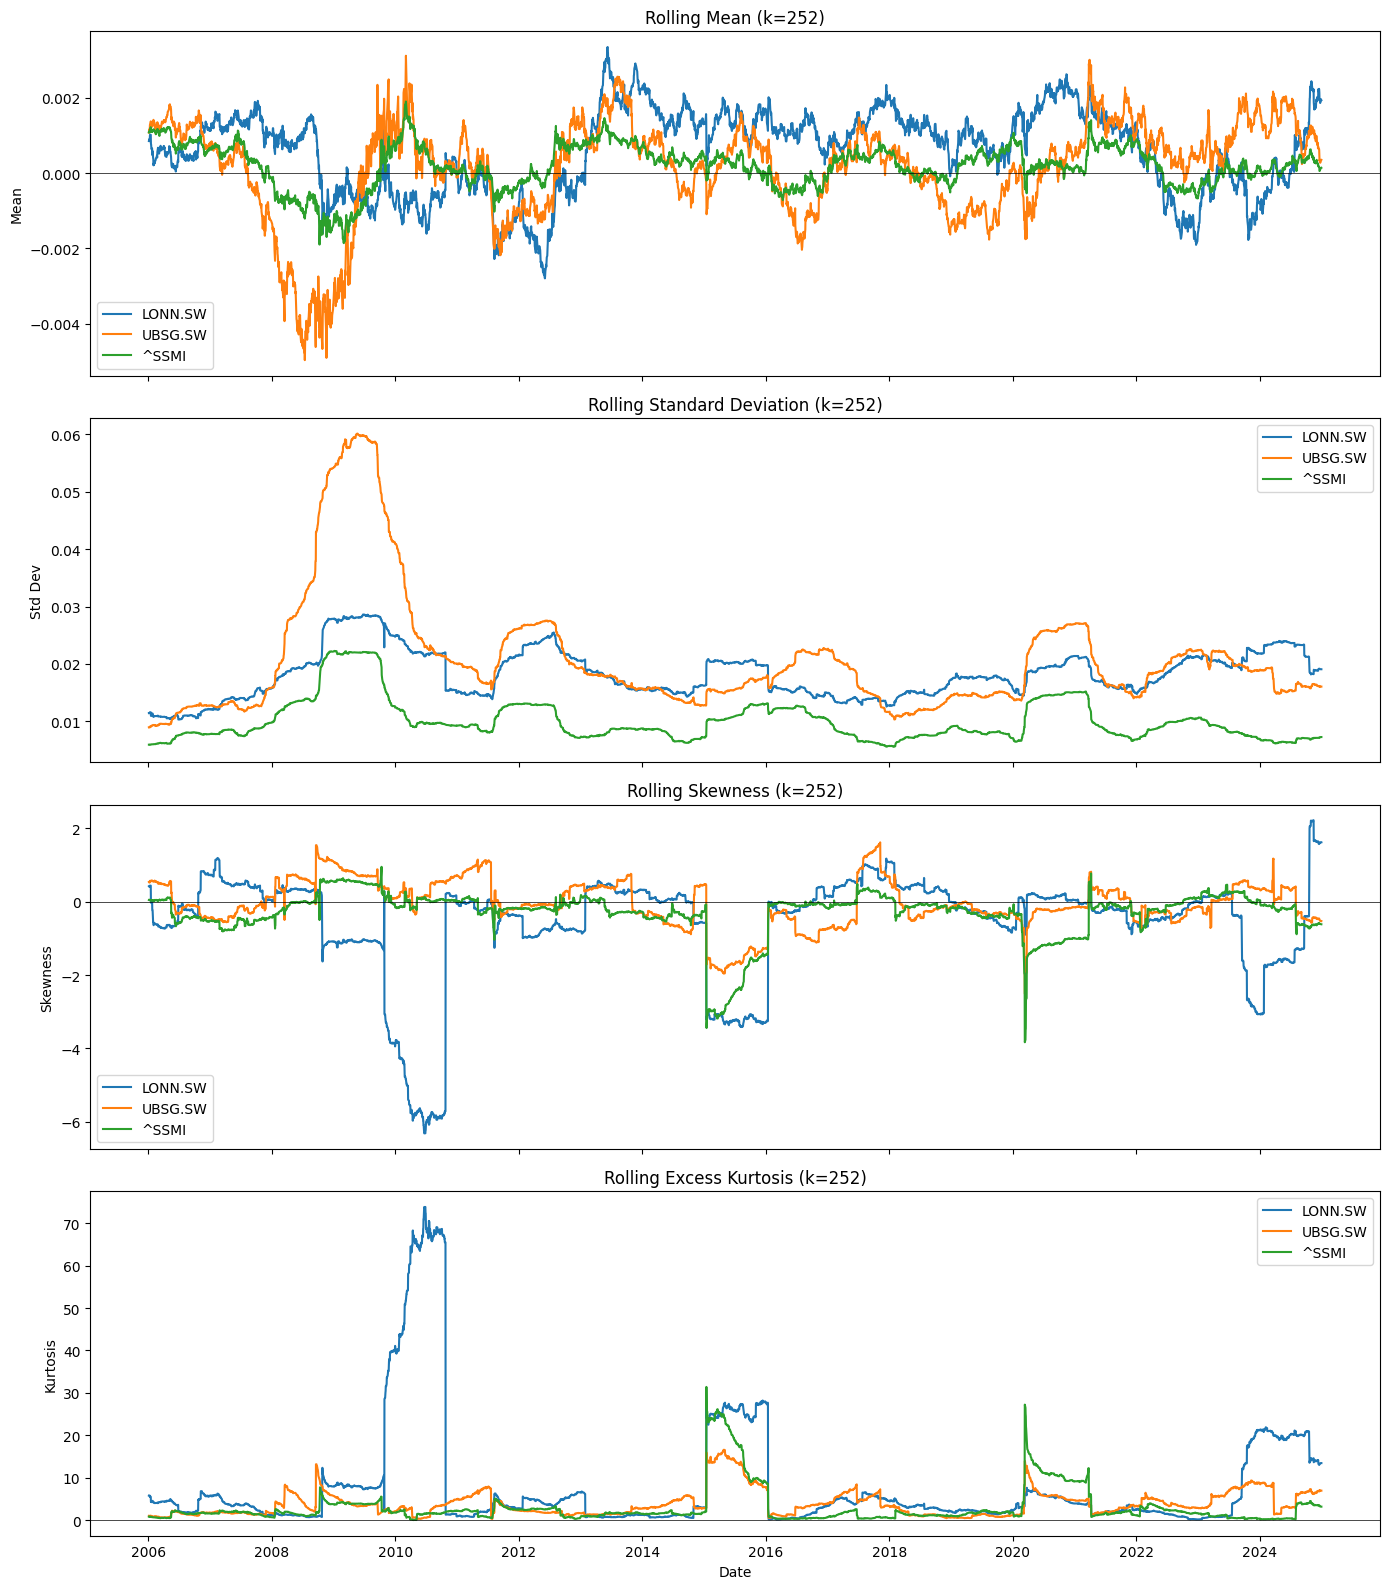

In [20]:
# Exercise 4: Rolling window statistics (k=252, ~1 year)
k = 252

# 4a) Rolling mean, std, skewness, kurtosis
rolling_mean = returns.rolling(window=k).mean()
rolling_std = returns.rolling(window=k).std()
rolling_skew = returns.rolling(window=k).skew()
rolling_kurt = returns.rolling(window=k).apply(lambda x: x.kurtosis(), raw=False)

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

for col in returns.columns:
    axes[0].plot(rolling_mean[col], label=col)
axes[0].set_title(f'Rolling Mean (k={k})')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].legend()
axes[0].set_ylabel('Mean')

for col in returns.columns:
    axes[1].plot(rolling_std[col], label=col)
axes[1].set_title(f'Rolling Standard Deviation (k={k})')
axes[1].legend()
axes[1].set_ylabel('Std Dev')

for col in returns.columns:
    axes[2].plot(rolling_skew[col], label=col)
axes[2].set_title(f'Rolling Skewness (k={k})')
axes[2].axhline(0, color='k', linewidth=0.5)
axes[2].legend()
axes[2].set_ylabel('Skewness')

for col in returns.columns:
    axes[3].plot(rolling_kurt[col], label=col)
axes[3].set_title(f'Rolling Excess Kurtosis (k={k})')
axes[3].axhline(0, color='k', linewidth=0.5)
axes[3].legend()
axes[3].set_ylabel('Kurtosis')

plt.xlabel('Date')
plt.tight_layout()
plt.show()


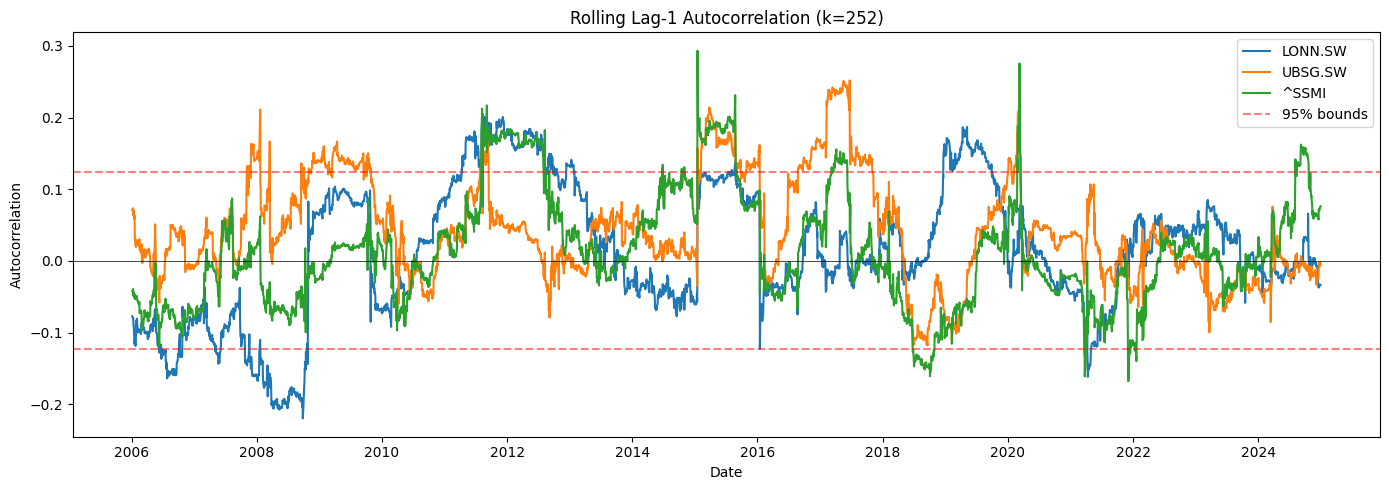

In [21]:
# 4b) Rolling first-order autocorrelation (k=252)
rolling_autocorr_1 = returns.rolling(window=k).apply(
    lambda x: pd.Series(x).autocorr(lag=1), raw=False
)

plt.figure(figsize=(14, 5))
for col in returns.columns:
    plt.plot(rolling_autocorr_1[col], label=col)
plt.title(f'Rolling Lag-1 Autocorrelation (k={k})')
plt.axhline(0, color='k', linewidth=0.5)
plt.axhline(1.96 / np.sqrt(k), color='red', linestyle='--', alpha=0.5, label='95% bounds')
plt.axhline(-1.96 / np.sqrt(k), color='red', linestyle='--', alpha=0.5)
plt.xlabel('Date')
plt.ylabel('Autocorrelation')
plt.legend()
plt.tight_layout()
plt.show()


### Comments on how results vary with t:

**Rolling Mean:** The rolling mean fluctuates significantly over time, alternating between positive and negative periods. Crisis periods (2008 GFC, 2020 COVID) show sharp drops in rolling mean. This confirms that expected returns are **not constant** — they are time-varying.

**Rolling Standard Deviation:** Volatility is clearly time-varying and clusters. It spikes during crises (2008, 2011 European debt crisis, 2020) and is lower during calm periods. This is consistent with **volatility clustering** — a well-known stylized fact of financial returns.

**Rolling Skewness:** Skewness changes sign over time, meaning the asymmetry of the return distribution is not stable. During crises, skewness tends to become more negative (more frequent large negative returns).

**Rolling Kurtosis:** Excess kurtosis also varies substantially over time. It spikes when extreme events enter or leave the rolling window, confirming that **fat tails are episodic** rather than constant.

**Rolling Autocorrelation and Ljung-Box:** Linear predictability is not constant — some periods show significant autocorrelation (p-value < 0.05) while others do not. This suggests that market efficiency varies over time, with returns being more predictable during certain regimes (e.g., crises) and less predictable during calm periods.

**Overall:** The full-sample statistics from Exercise 1 represent time-averages that mask substantial temporal variation. The rolling window approach reveals that all key properties of return distributions — mean, volatility, skewness, kurtosis, and predictability — are **time-varying**, which has important implications for risk management and portfolio construction.
